# Universal Grammar Generative Model

In [1]:
INSTALL = false

if INSTALL
    using Pkg
    Pkg.activate("psyc261")
    Pkg.add(["JLD2", "Distributions", "ProgressMeter", "Parameters", 
            "Random", "Gen", "Plots", "PyCall", "Conda", "JSON3"])
end

In [2]:
include("../src/ug_model.jl")
using .UGmodel

In [3]:
using Pkg
Pkg.activate("psyc261")
using JLD2
using Distributions
using ProgressMeter
using Parameters
using Random
using Gen, Plots
using PyCall
np = pyimport("numpy")

  Activating project at `~/Algorithms-of-the-Mind/aom/notebooks/psyc261`


PyObject <module 'numpy' from '/home/psyc2610_jdp69/.local/lib/python3.11/site-packages/numpy/__init__.py'>

## Generative Model

In [4]:
const NOUNS = UGmodel.LEXICON.nouns
const VERBS_TRANS = UGmodel.LEXICON.verbs_trans
const VERBS_INTR = UGmodel.LEXICON.verbs_intr
const ADJECTIVES = UGmodel.LEXICON.adjectives
const WH_WORD = UGmodel.LEXICON.wh_word

"what"

In [5]:
# Creating fixed size vocabulary
const VOCAB = unique(vcat(["PAD", WH_WORD], NOUNS, VERBS_TRANS, VERBS_INTR, ADJECTIVES))
const VOCAB_SIZE = length(VOCAB)
const WORD_TO_IDX = Dict(w => i for (i,w) in enumerate(VOCAB))
const MAX_SENT_LEN = 6

6

In [6]:
# Noise constant to account for misunderstandings, slip of the tongue etc.
# Generates ungrammatical sentences
const NOISE_PROB = 0.1

0.1

In [7]:
function emission_probs(target_idx::Int; V::Int = VOCAB_SIZE, epsilon::Float64 = 0.05)
    @assert 0 < epsilon < 1
    probs = fill(epsilon / (V-1), V)
    probs[target_idx] = 1.0 -epsilon

    return probs

end

emission_probs (generic function with 1 method)

In [8]:
@gen function corpus_model(num_sentences::Int)
    # === Universal Grammar paramaters (theta) ===
    # Head direction: 1 = Verb-Object (VO), 0 = Object-Verb(OV)
    hd = @trace(bernoulli(0.5), :head_direction)

    # Subject drop: 1 = subject may be dropped, 0 = subject always present
    sd = @trace(bernoulli(0.5), :subject_drop)

    # Adjective order: 1 = Adjective-Noun (AN), 0 = Noun-Adjective (NA)
    ao = @trace(bernoulli(0.5), :adj_order)

    # Wh-fronting in question: 1 = wh-word at front, 0 = in-situ
    wh = @trace(bernoulli(0.5), :wh_fronting)
    
    sentences = Vector{Vector{String}}(undef, num_sentences)

    for i in 1:num_sentences
        # Utterance type: 1 = transitive declarative, 2 = intransitive, 3 = transitive question
        utt_type = @trace(categorical([0.4, 0.3, 0.3]), (:utt_type, i))

        # Sample lexical items
        subj_idx = @trace(categorical(fill(1/length(NOUNS), length(NOUNS))), (:subj, i))
        obj_idx = @trace(categorical(fill(1/length(NOUNS), length(NOUNS))), (:obj, i))
        adj_idx = @trace(categorical(fill(1/length(ADJECTIVES), length(ADJECTIVES))), (:adj, i))

        if utt_type == 1 || utt_type == 3
            v_idx = @trace(categorical(fill(1/length(VERBS_TRANS), length(VERBS_TRANS))), (:v_trans, i))
            verb = VERBS_TRANS[v_idx]
        else
            v_idx = @trace(categorical(fill(1/length(VERBS_INTR), length(VERBS_INTR))), (:v_intr, i))
            verb = VERBS_INTR[v_idx]
        end

        subj = NOUNS[subj_idx]
        obj = NOUNS[obj_idx]
        adj = ADJECTIVES[adj_idx]

        # Add adjective order error
        ao_slip = @trace(bernoulli(NOISE_PROB), (:ao_slip, i))
        effective_ao = ao_slip ? !ao : ao
        
        # Build NP for subject and object, respecting adjective order and taking error into account
        function make_np(noun::String, adj::String, order_rule::Bool)
            if order_rule == 1
                return [adj, noun] # Adj N
            else
                return [noun, adj] # N Adj
            end
        end

        subj_np = make_np(subj, adj, effective_ao)
        obj_np = make_np(obj, adj, effective_ao)

        # Add head direction error
        hd_slip = @trace(bernoulli(NOISE_PROB), (:hd_slip, i))
        effective_hd = hd_slip ? !hd : hd

        # Base clause word order for transitive
        vp = Vector{String}()
        if utt_type == 1 || utt_type == 3
            # Verb-Object vs. Object-Verb in the VP
            vp = (effective_hd == 1) ? vcat([verb], obj_np) : vcat(obj_np, [verb])
        else
            # Intransitive: just the verb
            vp = [verb]
        end

        # Add subject drop error
        sd_slip = @trace(bernoulli(NOISE_PROB), (:sd_slip, i))
        effective_sd = sd_slip ? !sd : sd

        # Drop subject if SD = 1
        drop_subj = (effective_sd == 1) ? @trace(bernoulli(0.5), (:drop_subj, i)) : 0

        clause = Vector{String}()

        if drop_subj == 0
            append!(clause, subj_np)
        end
        
        append!(clause, vp)

        # Handle questions
        if utt_type == 3
            wh_slip = @trace(bernoulli(NOISE_PROB), (:wh_slip, i))
            effective_wh = wh_slip ? !wh : wh
            
            if effective_wh == 1
                # wh-fronting
                clause = vcat([WH_WORD], clause)
            else
                # wh in-situ (append at the end)
                push!(clause, WH_WORD)
            end
        end

        sentences[i] = clause

        for pos in 1:MAX_SENT_LEN
            word = pos <= length(clause) ? clause[pos] : "PAD"
            vocab_idx = WORD_TO_IDX[word]
            probs = emission_probs(vocab_idx; V=VOCAB_SIZE, epsilon = NOISE_PROB * 0.5)
            @trace(categorical(probs), (:token, i, pos))
        end
    end

    return sentences
end

DynamicDSLFunction{Any}(Dict{Symbol, Any}(), Dict{Symbol, Any}(), Type[Int64], false, Union{Nothing, Some{Any}}[nothing], var"##corpus_model#292", Bool[0], false)

In [9]:
trace = simulate(corpus_model, (10,))
sentences = get_retval(trace)
theta = (
    hd = trace[:head_direction],
    sd = trace[:subject_drop],
    ao = trace[:adj_order],
    wh = trace[:wh_fronting]
)
theta

(hd = false, sd = true, ao = true, wh = false)

In [10]:
@gen function corpus_given_theta(hd::Bool, sd::Bool, ao::Bool, wh::Bool, num_sentences::Int)
    sentences = Vector{Vector{String}}(undef, num_sentences)

    for i in 1:num_sentences
        utt_type = @trace(categorical([0.4, 0.3, 0.3]), (:utt_type, i))

        subj_idx = @trace(categorical(fill(1/length(NOUNS), length(NOUNS))), (:subj, i))
        obj_idx = @trace(categorical(fill(1/length(NOUNS), length(NOUNS))), (:obj, i))
        adj_idx = @trace(categorical(fill(1/length(ADJECTIVES), length(ADJECTIVES))), (:adj, i))

        if utt_type == 1 || utt_type == 3
            v_idx = @trace(categorical(fill(1/length(VERBS_TRANS), length(VERBS_TRANS))), (:v_trans, i))
            verb = VERBS_TRANS[v_idx]
        else
            v_idx = @trace(categorical(fill(1/length(VERBS_INTR), length(VERBS_INTR))), (:v_intr, i))
            verb = VERBS_INTR[v_idx]
        end

        subj = NOUNS[subj_idx]
        obj = NOUNS[obj_idx]
        adj = ADJECTIVES[adj_idx]

        function make_np(noun::String, adj::String)
            if ao == 1
                return [adj, noun] # Adj N
            else
                return [noun, adj] # N Adj
            end
        end
        
        subj_np = make_np(subj, adj)
        obj_np = make_np(obj, adj)

        drop_subj = (sd == 1) ? @trace(bernoulli(0.5), (:drop_subj, i)) : 0

        if utt_type == 1 || utt_type == 3
            vp = (hd == 1) ? vcat([verb], obj_np) : vcat(obj_np, [verb])
        else
            vp = [verb]
        end

        clause = Vector{String}()

        if drop_subj == 0
            append!(clause, subj_np)
        end
        append!(clause, vp)

        if utt_type == 3
            if wh == 1
                clause = vcat([WH_WORD], clause)
            else
                push!(clause, WH_WORD)
            end
        end

        sentences[i] = clause
    end

    return sentences
end

DynamicDSLFunction{Any}(Dict{Symbol, Any}(), Dict{Symbol, Any}(), Type[Bool, Bool, Bool, Bool, Int64], false, Union{Nothing, Some{Any}}[nothing, nothing, nothing, nothing, nothing], var"##corpus_given_theta#293", Bool[0, 0, 0, 0, 0], false)

In [11]:
using JSON3

SAVE = false

if SAVE
    theta = (hd=false, sd=false, ao=true, wh=true)
    num_sentences = 100
    
    trace = simulate(corpus_given_theta, (theta.hd, theta.sd, theta.ao, theta.wh, num_sentences))
    corpus = get_retval(trace)
    
    open("../data/ug_language1.json", "w") do io
        JSON3.write(io, Dict("theta" => theta, "sentences" => corpus))
    end
end

## Neural Network

In [12]:
# Neural net params
const NUM_SENTS_TRAIN = 10
const INPUT_DIM = VOCAB_SIZE * MAX_SENT_LEN * NUM_SENTS_TRAIN
H = 128

128

In [13]:
mutable struct NeuralNetParams
    W1::Matrix{Float64}  
    b1::Vector{Float64}  
    W2::Matrix{Float64}  
    b2::Vector{Float64}  
end

### Encoding the sentences

In [14]:
# Convert sentences into a flattened one hot encoded vector
function encode_corpus(sentences::Vector{Vector{String}})
    encoded = zeros(Float64, INPUT_DIM)

    cursor = 0
    for i in 1:NUM_SENTS_TRAIN
        if i > length(sentences) break end

        sent = sentences[i]
        for j in 1:MAX_SENT_LEN
            word = j <= length(sent) ? sent[j] : "PAD"

            vocab_idx = WORD_TO_IDX[word]

            encoded[cursor * VOCAB_SIZE + vocab_idx] = 1.0
            cursor += 1
        end
    end

    return encoded
end

encode_corpus (generic function with 1 method)

### Creating the innate solver neural network (Variational Approximation)

In [44]:
σ(x) = tanh.(x)
sigmoid(x) = 1.0 ./ (1.0 .+ exp.(-x))

@gen function innate_solver(input_vector::Vector{Float64})
    @param W1::Matrix{Float64}
    @param b1::Vector{Float64}
    @param W2::Matrix{Float64}
    @param b2::Vector{Float64}

    hidden_layer = σ(W1 * input_vector + b1)
    output = W2 * hidden_layer + b2

    probs = sigmoid(output)

    for i in 1:4
        @trace(Gen.bernoulli(probs[i]), (:param, i))
    end
    
    return probs
end

init_weight(out, inc) = randn(out, inc) * 0.01
init_param!(innate_solver, :W1, init_weight(H, INPUT_DIM))
init_param!(innate_solver, :b1, zeros(H))
init_param!(innate_solver, :W2, init_weight(4, H))
init_param!(innate_solver, :b2, zeros(4))

4-element Vector{Float64}:
 0.0
 0.0
 0.0
 0.0

### Generating synthetic languages from the GM

In [45]:
function supervised_training_batch_generator()
    # 1) sample from the generative model -> gives us ground-truth theta + sentences
    tr = simulate(corpus_model, (NUM_SENTS_TRAIN,))
    sentences = get_retval(tr)

    # encode input (the innate_solver expects a single input vector)
    input_vec = encode_corpus(sentences)

    # create constraints: a ChoiceMap of the true theta values
    constraints = Gen.choicemap()
    constraints[(:param, 1)] = tr[:head_direction]
    constraints[(:param, 2)] = tr[:subject_drop]
    constraints[(:param, 3)] = tr[:adj_order]
    constraints[(:param, 4)] = tr[:wh_fronting]

    # return (inputs_tuple, constraints)
    return ((input_vec,), constraints)
end

supervised_training_batch_generator (generic function with 1 method)

### Training the innate solver

In [ ]:
update = Gen.ParamUpdate(Gen.FixedStepGradientDescent(0.001), innate_solver)

NUM_EPOCHS = 200
EPOCH_SIZE = 50

TRAIN = true

if TRAIN
    losses = Float64[]
    
    for epoch in 1:NUM_EPOCHS
        epoch_loss = 0.0
        
        for i in 1:EPOCH_SIZE
            (args, constraints) = supervised_training_batch_generator()
            (trace, weight) = generate(innate_solver, args, constraints)
            
            Gen.accumulate_param_gradients!(trace)
            
            epoch_loss += -get_score(trace)
        end
        
        Gen.apply!(update)
        
        avg_loss = epoch_loss / EPOCH_SIZE
        push!(losses, avg_loss)
        
        if epoch == 1 || epoch % 10 == 0
            println("Epoch $epoch: avg loss = $(round(avg_loss, digits=4))")
        end
    end

    plot(losses, label = "Loss (Neg LogLik)", xlabel = "Epochs", title = "Training Innate Solver")
end

Epoch 1: avg loss = 2.7725
Epoch 10: avg loss = 2.7665
Epoch 20: avg loss = 2.7581


## Neural network (Manual gradient)

## Comparison Innate Solver vs Naive Learner

In [18]:
target_theta = (hd=true, sd=false, ao=true, wh=true)

target_constraints = Gen.choicemap()
target_constraints[:head_direction] = target_theta.hd
target_constraints[:subject_drop] = target_theta.sd
target_constraints[:adj_order] = target_theta.ao
target_constraints[:wh_fronting] = target_theta.wh

tr_target, _ = generate(corpus_model, (NUM_SENTS_TRAIN,), target_constraints)
observed_sentences = get_retval(tr_target)
observed_input_vec = encode_corpus(observed_sentences)

function mh_step(tr)
    tr, _ = mh(tr, select(:head_direction))
    tr, _ = mh(tr, select(:subject_drop))
    tr, _ = mh(tr, select(:adj_order))
    tr, _ = mh(tr, select(:wh_fronting))
    return tr
end

function is_correct(tr)
    return tr[:head_direction] == target_theta.hd &&
           tr[:subject_drop] == target_theta.sd &&
           tr[:adj_order] == target_theta.ao &&
           tr[:wh_fronting] == target_theta.wh
end

naive_trace, _ = generate(corpus_model, (NUM_SENTS_TRAIN, ), Gen.choicemap())
naive_accuracy = []
for i in 1:500
    global naive_trace = mh_step(naive_trace)
    push

LoadError: syntax: incomplete: "for" at In[18]:30 requires end

In [23]:
# ============================================================================
# NEURAL NETWORK FOR UNIVERSAL GRAMMAR PARAMETER LEARNING
# ============================================================================

# ----------------------------------------------------------------------------
# 1. Define Helper Functions
# ----------------------------------------------------------------------------

σ(x) = tanh.(x)
sigmoid(x) = 1.0 ./ (1.0 .+ exp.(-x))

# ----------------------------------------------------------------------------
# 2. Define Parameter Structure
# ----------------------------------------------------------------------------

mutable struct NeuralNetParams
    W1::Matrix{Float64}  # Input to hidden weights
    b1::Vector{Float64}  # Hidden layer bias
    W2::Matrix{Float64}  # Hidden to output weights
    b2::Vector{Float64}  # Output layer bias
end

# ----------------------------------------------------------------------------
# 3. Initialize Network Parameters
# ----------------------------------------------------------------------------

function initialize_network(input_dim::Int, hidden_dim::Int, output_dim::Int)
    init_weight(out, inc) = randn(out, inc) * 0.01
    
    return NeuralNetParams(
        init_weight(hidden_dim, input_dim),  # W1
        zeros(hidden_dim),                    # b1
        init_weight(output_dim, hidden_dim),  # W2
        zeros(output_dim)                     # b2
    )
end

# ----------------------------------------------------------------------------
# 4. Forward Pass
# ----------------------------------------------------------------------------

function forward_pass(params::NeuralNetParams, input_vec::Vector{Float64})
    z1 = params.W1 * input_vec + params.b1
    h = tanh.(z1)
    z2 = params.W2 * h + params.b2
    probs = sigmoid(z2)
    
    return probs, h, z1
end

# ----------------------------------------------------------------------------
# 5. Backward Pass (Gradient Computation)
# ----------------------------------------------------------------------------

function backward_pass(params::NeuralNetParams, 
                       input_vec::Vector{Float64},
                       probs::Vector{Float64},
                       h::Vector{Float64},
                       true_labels::Vector{Float64})
    # Output layer gradients
    dz2 = probs - true_labels  # BCE + sigmoid derivative
    dW2 = dz2 * h'
    db2 = dz2
    
    # Hidden layer gradients
    dh = params.W2' * dz2
    dz1 = dh .* (1.0 .- h.^2)  # tanh derivative
    dW1 = dz1 * input_vec'
    db1 = dz1
    
    return dW1, db1, dW2, db2
end

# ----------------------------------------------------------------------------
# 6. Compute Loss
# ----------------------------------------------------------------------------

function compute_loss(probs::Vector{Float64}, true_labels::Vector{Float64})
    eps = 1e-10
    probs_clamped = clamp.(probs, eps, 1.0 - eps)
    loss = -sum(true_labels .* log.(probs_clamped) .+ 
                (1.0 .- true_labels) .* log.(1.0 .- probs_clamped))
    return loss
end

# ----------------------------------------------------------------------------
# 7. Training Loop
# ----------------------------------------------------------------------------

function train_network!(params::NeuralNetParams,
                        num_epochs::Int,
                        epoch_size::Int,
                        learning_rate::Float64;
                        verbose::Bool=true)
    losses = Float64[]
    
    for epoch in 1:num_epochs
        epoch_loss = 0.0
        
        for batch in 1:epoch_size
            # Generate training example from generative model
            tr = simulate(corpus_model, (NUM_SENTS_TRAIN,))
            sentences = get_retval(tr)
            input_vec = encode_corpus(sentences)
            
            # Get true labels
            true_labels = Float64[
                tr[:head_direction],
                tr[:subject_drop],
                tr[:adj_order],
                tr[:wh_fronting]
            ]
            
            # Forward pass
            probs, h, z1 = forward_pass(params, input_vec)
            
            # Compute gradients
            dW1, db1, dW2, db2 = backward_pass(params, input_vec, probs, h, true_labels)
            
            # Update parameters (gradient descent)
            params.W1 -= learning_rate * dW1
            params.b1 -= learning_rate * vec(db1)
            params.W2 -= learning_rate * dW2
            params.b2 -= learning_rate * vec(db2)
            
            # Track loss
            epoch_loss += compute_loss(probs, true_labels)
        end
        
        avg_loss = epoch_loss / epoch_size
        push!(losses, avg_loss)
        
        if verbose && (epoch == 1 || epoch % 10 == 0)
            println("Epoch $epoch: avg loss = $(round(avg_loss, digits=4))")
        end
    end
    
    return losses
end

# ----------------------------------------------------------------------------
# 8. Prediction Function
# ----------------------------------------------------------------------------

function predict(params::NeuralNetParams, input_vec::Vector{Float64})
    probs, _, _ = forward_pass(params, input_vec)
    
    # Threshold at 0.5 for binary predictions
    predictions = (
        hd = probs[1] > 0.5,
        sd = probs[2] > 0.5,
        ao = probs[3] > 0.5,
        wh = probs[4] > 0.5
    )
    
    return predictions, probs
end

# ----------------------------------------------------------------------------
# 9. Test/Evaluation Function
# ----------------------------------------------------------------------------

function test_network(params::NeuralNetParams, 
                      test_theta::NamedTuple,
                      num_test::Int=10;
                      verbose::Bool=true)
    correct = 0
    
    if verbose
        println("\n" * "="^60)
        println("Testing Network on θ = $test_theta")
        println("="^60)
    end
    
    for i in 1:num_test
        # Generate test data with known theta
        constraints = Gen.choicemap()
        constraints[:head_direction] = test_theta.hd
        constraints[:subject_drop] = test_theta.sd
        constraints[:adj_order] = test_theta.ao
        constraints[:wh_fronting] = test_theta.wh
        
        tr, _ = generate(corpus_model, (NUM_SENTS_TRAIN,), constraints)
        sentences = get_retval(tr)
        input_vec = encode_corpus(sentences)
        
        # Get predictions
        pred, probs = predict(params, input_vec)
        
        # Check if correct
        is_correct = (pred.hd == test_theta.hd && 
                     pred.sd == test_theta.sd && 
                     pred.ao == test_theta.ao && 
                     pred.wh == test_theta.wh)
        
        if is_correct
            correct += 1
        end
        
        if verbose
            println("Test $i: " *
                    "True=($(test_theta.hd),$(test_theta.sd),$(test_theta.ao),$(test_theta.wh)), " *
                    "Pred=($(pred.hd),$(pred.sd),$(pred.ao),$(pred.wh)), " *
                    "Probs=$(round.(probs, digits=3)) " *
                    (is_correct ? "✓" : "✗"))
        end
    end
    
    accuracy = correct / num_test
    if verbose
        println("="^60)
        println("Test Accuracy: $(round(accuracy * 100, digits=1))%")
        println("="^60)
    end
    
    return accuracy
end

# ============================================================================
# USAGE EXAMPLE
# ============================================================================

"""
# Step 1: Initialize the network
nn_params = initialize_network(INPUT_DIM, 128, 4)

# Step 2: Train the network
println("Training neural network...")
losses = train_network!(nn_params, 50, 50, 0.001, verbose=true)

# Step 3: Plot training curve
plot(losses, label="Training Loss", xlabel="Epoch", ylabel="BCE Loss", 
     title="Neural Network Training", linewidth=2, legend=:topright)

# Step 4: Test on various grammar configurations
test_configs = [
    (hd=true, sd=false, ao=true, wh=true),
    (hd=false, sd=false, ao=true, wh=false),
    (hd=true, sd=true, ao=false, wh=true),
    (hd=false, sd=true, ao=false, wh=false)
]

for config in test_configs
    test_network(nn_params, config, 20, verbose=true)
end
"""

"# Step 1: Initialize the network\nnn_params = initialize_network(INPUT_DIM, 128, 4)\n\n# Step 2: Train the network\nprintln(\"Training neural network...\")\nlosses = train_network!(nn_params, 50, 50, 0.001, verbose=true)\n\n# Step 3: Plot training curve\nplot(losses, label=\"Traini" ⋯ 175 bytes ⋯ "gs = [\n    (hd=true, sd=false, ao=true, wh=true),\n    (hd=false, sd=false, ao=true, wh=false),\n    (hd=true, sd=true, ao=false, wh=true),\n    (hd=false, sd=true, ao=false, wh=false)\n]\n\nfor config in test_configs\n    test_network(nn_params, config, 20, verbose=true)\nend\n"

Initializing neural network...

Training neural network...
Epoch 1: avg loss = 2.7731
Epoch 10: avg loss = 2.7674
Epoch 20: avg loss = 2.7538
Epoch 30: avg loss = 2.7484
Epoch 40: avg loss = 2.7339
Epoch 50: avg loss = 2.7027
Epoch 60: avg loss = 2.6588
Epoch 70: avg loss = 2.62
Epoch 80: avg loss = 2.5509
Epoch 90: avg loss = 2.4593
Epoch 100: avg loss = 2.3962
Epoch 110: avg loss = 2.3336
Epoch 120: avg loss = 2.2011
Epoch 130: avg loss = 2.1513
Epoch 140: avg loss = 2.0861
Epoch 150: avg loss = 2.0261
Epoch 160: avg loss = 1.9216
Epoch 170: avg loss = 1.8381
Epoch 180: avg loss = 1.7047
Epoch 190: avg loss = 1.6416
Epoch 200: avg loss = 1.5567


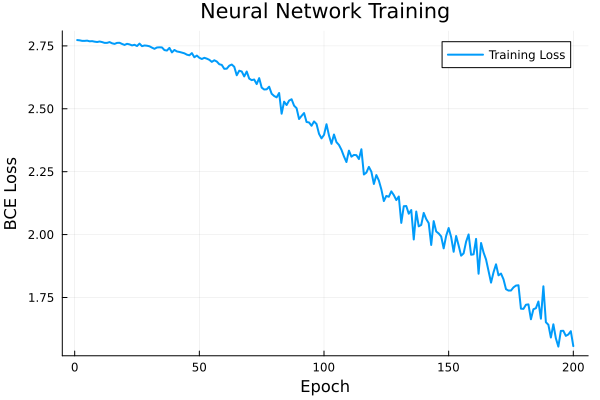


TESTING ON DIFFERENT GRAMMAR CONFIGURATIONS

Testing Network on θ = (hd = true, sd = false, ao = true, wh = true)
Test 1: True=(true,false,true,true), Pred=(true,false,true,false), Probs=[0.502, 0.423, 0.98, 0.464] ✗
Test 2: True=(true,false,true,true), Pred=(true,false,true,true), Probs=[0.635, 0.273, 0.933, 0.504] ✓
Test 3: True=(true,false,true,true), Pred=(true,false,false,true), Probs=[0.599, 0.46, 0.439, 0.645] ✗
Test 4: True=(true,false,true,true), Pred=(true,true,true,false), Probs=[0.567, 0.572, 0.917, 0.399] ✗
Test 5: True=(true,false,true,true), Pred=(true,false,true,true), Probs=[0.588, 0.402, 0.819, 0.634] ✓
Test 6: True=(true,false,true,true), Pred=(true,false,true,true), Probs=[0.644, 0.243, 0.608, 0.568] ✓
Test 7: True=(true,false,true,true), Pred=(true,false,true,true), Probs=[0.624, 0.385, 0.914, 0.726] ✓
Test 8: True=(true,false,true,true), Pred=(true,false,true,true), Probs=[0.654, 0.317, 0.878, 0.576] ✓
Test 9: True=(true,false,true,true), Pred=(true,false,true,tr

In [24]:
# ============================================================================
# NEURAL NETWORK TRAINING
# ============================================================================

# Copy all the code from the artifact above, then:

# Initialize network
const HIDDEN_DIM = 128
const OUTPUT_DIM = 4

println("Initializing neural network...")
nn_params = initialize_network(INPUT_DIM, HIDDEN_DIM, OUTPUT_DIM)

# Train network
println("\nTraining neural network...")
losses = train_network!(nn_params, NUM_EPOCHS, EPOCH_SIZE, 0.001, verbose=true)

# Plot training curve
p1 = plot(losses, 
          label="Training Loss", 
          xlabel="Epoch", 
          ylabel="BCE Loss", 
          title="Neural Network Training", 
          linewidth=2, 
          legend=:topright,
          size=(600, 400))

display(p1)

# Test on multiple configurations
println("\n" * "="^60)
println("TESTING ON DIFFERENT GRAMMAR CONFIGURATIONS")
println("="^60)

test_configs = [
    (hd=true, sd=false, ao=true, wh=true),
    (hd=false, sd=false, ao=true, wh=false),
    (hd=true, sd=true, ao=false, wh=true),
    (hd=false, sd=true, ao=false, wh=false)
]

accuracies = []
for config in test_configs
    acc = test_network(nn_params, config, 20, verbose=true)
    push!(accuracies, acc)
    println()
end

println("Average Accuracy: $(round(mean(accuracies) * 100, digits=1))%")